In [14]:
import pandas as pd
data = pd.read_csv("../data/data_preprossing.csv")
data.shape

(652, 13)

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X = data.drop(["List Price", "IPO_Name", "Date"] ,axis = 1)
y = data["List Price"]

X_train,X_test,y_train,y_test = train_test_split(X,y , test_size = 0.20 , random_state = 1)

model = RandomForestRegressor(random_state = 1)
model.fit(X_train ,y_train)
rf_pred = model.predict(X_test)

print(rf_pred[:10])



[ 13.9637  60.518   62.2672 111.5253 668.3685 141.3075 254.6955 551.2205
 765.9515 219.242 ]


In [16]:
comperison = pd.DataFrame({
    "Actual price" : y_test,
    "predicted price" : rf_pred
})
print(comperison)

     Actual price  predicted price
465         10.10          13.9637
441         55.80          60.5180
593         52.13          62.2672
458        110.00         111.5253
41         660.00         668.3685
..            ...              ...
195        360.50         364.6220
135        137.75         138.3420
411        313.00         317.3550
159        163.30         134.1309
250        141.00         127.4918

[131 rows x 2 columns]


In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, rf_pred)
rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
r2 = r2_score(y_test, rf_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 25.41050534351146
RMSE: 65.21915139388719
R2  : 0.9763402073689523


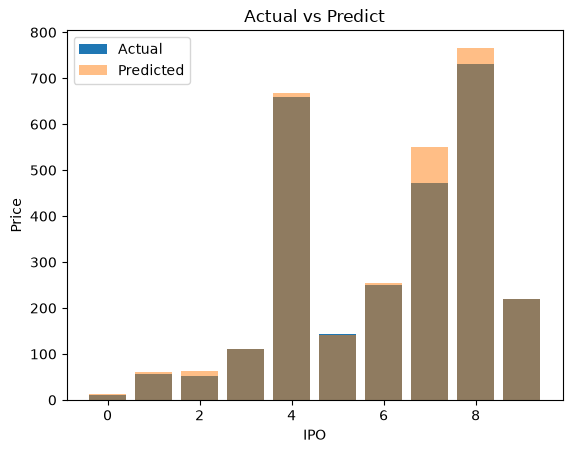

In [18]:
import matplotlib.pyplot as plt

plt.Figure(figsize=(10,6))

plt.bar(range(10), y_test[:10], label="Actual")
plt.bar(range(10), rf_pred[:10], alpha=0.5, label="Predicted")

plt.xlabel("IPO")
plt.ylabel("Price")
plt.title("Actual vs Predict")
plt.legend()

plt.show()

In [19]:
import joblib
joblib.dump(model , "random_forest.pkl")

['random_forest.pkl']